# AI4QC-2 Sentinel-2 L1C (JP2) — Step-by-step debug notebook
This notebook mirrors the `s2_l1c_data.py` pipeline, but runs interactively and plots intermediate steps (as James suggested).

In [1]:
# Choose ONE tile and a date range. The notebook will:
#  1) discover all L1C products for this tile between START_DATE and END_DATE
#  2) pick one product for step-by-step debugging (DEBUG_PRODUCT_INDEX)
#  3) optionally build a time-stacked Zarr cube at the end.
#
# Notes:
# - AWS Sentinel-2 bucket uses non-zero-padded month/day in the 'products' path: .../2025/7/9/...
# - Stored data is physically meaningful reflectance = DN/10000. No percentile stretch is applied to storage.
# - Any clipping/stretching is only for plotting quicklooks.

IN_BUCKET = "sentinel-s2-l1c"

TILE = "56FQF"                 # e.g. "56FQF"
START_DATE = "2015-06-01"      # YYYY-MM-DD (inclusive)
END_DATE   = "2025-12-31"      # YYYY-MM-DD (inclusive)
# DEBUG_PRODUCT_INDEX = 0        # which product in the discovered list to use for debug plots

OUT_DIM = 128
QUANTIFICATION_VALUE = 10000.0
COVERAGE_THRESHOLD = 0.01  # fraction in [0,1]
MODE = "ALL12_FLOAT"   # options: "ALL12_FLOAT", "RGB_FLOAT", "RGB_UINT16"

# Zarr output name (local). A time-stacked cube will use this name.
ZARR_NAME = f"s2_l1c_tile_{TILE}_{START_DATE}_to_{END_DATE}_{MODE}.zarr"

# USE_DEBUG_DOWNSCALE = True   # True for single-product debug plots; False for bulk time stack
PID_DTYPE_LEN = 128

# DL_THREADS_PER_WORKER = 2   # 4–6 is usually enough
MAX_WORKERS = 10
BATCH_SIZE = 128             # 16 or 32 recommended (optional; see section 3)
USE_BATCH_WRITES = True     # set False to keep current time=1 appends
AWS_PROFILE = "source-keys"
AWS_REGION = "eu-central-1"   # or whatever region you normally use

OUTPUT_DIR = f"outputs/{TILE}"

In [2]:
BANDS_ALL12 = ["B01","B02","B03","B04","B05","B06","B07","B08","B8A","B09","B11","B12"]
BANDS_RGB   = ["B04","B03","B02"]

if MODE == "ALL12_FLOAT":
    BANDS = BANDS_ALL12
elif MODE in ("RGB_FLOAT", "RGB_UINT16"):
    BANDS = BANDS_RGB
else:
    raise ValueError(f"Unknown MODE={MODE}")

## 1) Imports

In [3]:
from __future__ import annotations

import os
import re
import json
# import shutil
# import tempfile
import datetime as dt
from typing import Dict, List, Optional, Tuple

import boto3
import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.transform import Affine
# from rasterio.warp import reproject
import xarray as xr
# from PIL import Image

# import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor

from rasterio.session import AWSSession
import atexit
import shutil
import tempfile
import time

# MAX_WORKERS = max(1, (os.cpu_count() or 8) - 1)


In [4]:
from botocore.config import Config

S3_CONFIG = Config(
    retries={"max_attempts": 12, "mode": "adaptive"},
    connect_timeout=30,
    read_timeout=120,
)

def log_failure(log_path: str, pid: str, stage: str, err: Exception):
    rec = {
        "product_id": pid,
        "stage": stage,
        "error": repr(err),
        "ts_utc": dt.datetime.utcnow().isoformat() + "Z",
    }
    with open(log_path, "a") as f:
        f.write(json.dumps(rec) + "\n")


## 2) Helpers (same as script)

In [5]:
def parse_s3_uri(uri: str) -> Tuple[str, str]:
    if not uri.startswith("s3://"):
        raise ValueError(f"Not an s3:// URI: {uri}")
    parts = uri[5:].split("/", 1)
    bucket = parts[0]
    key = parts[1] if len(parts) > 1 else ""
    return bucket, key

def ensure_trailing_slash(s: str) -> str:
    return s if s.endswith("/") else s + "/"

def get_mgrs_tile_from_product_id(product_id: str) -> str:
    m = re.search(r"_T(\d{2}[A-Z]{3})_", product_id)
    if not m:
        raise ValueError(f"Could not parse MGRS tile from product id: {product_id}")
    return m.group(1)

def extract_datetime_token(product_id: str) -> str:
    m = re.search(r"_(\d{8}T\d{6})_", product_id)
    if not m:
        raise ValueError(f"Could not extract datetime token from product id: {product_id}")
    return m.group(1)

def list_s3_objects_requester_pays(s3_client, bucket: str, prefix: str) -> List[str]:
    paginator = s3_client.get_paginator("list_objects_v2")
    keys: List[str] = []
    for page in paginator.paginate(Bucket=bucket, Prefix=prefix, RequestPayer="requester"):
        for obj in page.get("Contents", []):
            keys.append(obj["Key"])
    return keys

# def download_s3_object_requester_pays(s3_client, bucket: str, key: str, local_path: str) -> None:
#     os.makedirs(os.path.dirname(local_path), exist_ok=True)
#     s3_client.download_file(bucket, key, local_path, ExtraArgs={"RequestPayer": "requester"})

def _is_bad_key(k: str) -> bool:
    kl = k.lower()
    base = os.path.basename(kl)
    if not kl.endswith(".jp2"):
        return True
    if "/preview/" in kl:
        return True
    if "/qi_data/" in kl or "/aux_data/" in kl:
        return True
    if base.startswith("msk") or "msk" in base or "mask" in base:
        return True
    if base == "tci.jp2" or base.endswith("_tci.jp2"):
        return True
    return False

BAND_RES = {
    "B01": "R60m",
    "B02": "R10m",
    "B03": "R10m",
    "B04": "R10m",
    "B05": "R20m",
    "B06": "R20m",
    "B07": "R20m",
    "B08": "R10m",
    "B8A": "R20m",
    "B09": "R60m",
    "B10": "R60m",
    "B11": "R20m",
    "B12": "R20m",
}

def find_jp2_band_keys(all_keys: List[str], bands: List[str]) -> Dict[str, str]:
    keys = [k for k in all_keys if not _is_bad_key(k)]

    def matches_band(k: str, band: str) -> bool:
        base = os.path.basename(k)
        return base == f"{band}.jp2" or base.endswith(f"_{band}.jp2")

    band_to_key: Dict[str, str] = {}
    for band in bands:
        # print(f"Looking for band {band}")
        candidates = [k for k in keys if matches_band(k, band)]
        if not candidates:
            some = sorted({os.path.basename(x) for x in keys})[:30]
            raise RuntimeError(
                f"No JP2 found for band {band} after filtering. Example JP2 basenames seen: {some}"
            )

        want_res = BAND_RES.get(band)
        if want_res:
            res_candidates = [k for k in candidates if f"/{want_res.lower()}/" in k.lower()]
            if res_candidates:
                band_to_key[band] = sorted(res_candidates, key=len)[0]
                continue

        band_to_key[band] = sorted(candidates, key=len)[0]

    return band_to_key

# def log_mask_and_dtype(jp2_path: str) -> None:
#     with rasterio.open(jp2_path) as src:
#         mask_flags = src.mask_flag_enums[0] if src.count >= 1 else []
#         print(f"[{os.path.basename(jp2_path)}] dtype={src.dtypes[0]} nodata={src.nodata} mask_flags={mask_flags}")
#         m = src.read_masks(1, out_shape=(min(64, src.height), min(64, src.width)))
#         print(f"[{os.path.basename(jp2_path)}] mask sample unique={np.unique(m)[:10]}")

def tile_to_tiles_prefix(tile: str, sensing_date: dt.date) -> str:
    utm = tile[:2]
    lat = tile[2]
    grid = tile[3:]
    y = f"{sensing_date.year:04d}"
    m = str(sensing_date.month)
    d = str(sensing_date.day)
    return f"tiles/{utm}/{lat}/{grid}/{y}/{m}/{d}/"

def sensing_date_from_product_id(product_id: str) -> dt.date:
    tok = extract_datetime_token(product_id)  # YYYYMMDDThhmmss
    return dt.datetime.strptime(tok, "%Y%m%dT%H%M%S").date()


_RIO_ENV = None

def worker_init(aws_profile, aws_region) -> None:
    global _RIO_ENV

    boto_session = (
        boto3.Session(profile_name=aws_profile, region_name=aws_region)
        if aws_profile
        else boto3.Session(region_name=aws_region)
    )
    aws_sess = AWSSession(boto_session, requester_pays=True)

    _RIO_ENV = rasterio.Env(
        aws_sess,
        AWS_REGION=aws_region,
        AWS_REQUEST_PAYER="requester",
        GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR",
        GDAL_HTTP_MERGE_CONSECUTIVE_RANGES="YES",
        GDAL_HTTP_MULTIPLEX="YES",
        GDAL_HTTP_VERSION="2",
        GDAL_CACHEMAX=200,
        CPL_VSIL_CURL_CACHE_SIZE=200000000,
        VSI_CACHE="TRUE",
        VSI_CACHE_SIZE=5000000,
        CPL_VSIL_CURL_ALLOWED_EXTENSIONS=".jp2,.xml,.json,.JP2",
        PROJ_NETWORK="OFF",
        # GDAL_NUM_THREADS="1",
        # OPJ_NUM_THREADS="1",
    )
    _RIO_ENV.__enter__()
    atexit.register(lambda: _RIO_ENV.__exit__(None, None, None))

def s3_key_to_uri(bucket: str, key: str) -> str:
    return f"s3://{bucket}/{key}"

def read_band_out_reflectance_local(jp2_path: str) -> np.ndarray:
    with rasterio.open(jp2_path) as src:
        dn_ds = src.read(
            1,
            out_shape=(OUT_DIM, OUT_DIM),
            resampling=Resampling.average,
        ).astype(np.float32)
    return dn_ds / float(QUANTIFICATION_VALUE)

In [6]:
def iter_dates(start_date: str, end_date: str) -> List[dt.date]:
    s = dt.date.fromisoformat(start_date)
    e = dt.date.fromisoformat(end_date)
    if e < s:
        raise ValueError("END_DATE must be >= START_DATE")
    out = []
    d = s
    while d <= e:
        out.append(d)
        d += dt.timedelta(days=1)
    return out

def list_common_prefixes_requester_pays(
    s3_client, bucket: str, prefix: str, delimiter: str = "/"
) -> List[str]:
    paginator = s3_client.get_paginator("list_objects_v2")
    cps: List[str] = []

    # printed = False
    for page in paginator.paginate(
        Bucket=bucket, Prefix=prefix, Delimiter=delimiter, RequestPayer="requester"
    ):
        # if not printed:
        #     printed = True
        #     print("DEBUG list_objects_v2")
        #     print("  bucket:", bucket)
        #     print("  prefix:", prefix)
        #     print("  keys:", list(page.keys()))
        #     print("  KeyCount:", page.get("KeyCount"))
        #     print("  IsTruncated:", page.get("IsTruncated"))
        #     print("  CommonPrefixes:", len(page.get("CommonPrefixes", [])))
        #     print("  Contents:", len(page.get("Contents", [])))
        #     if page.get("CommonPrefixes"):
        #         print("  first CommonPrefix:", page["CommonPrefixes"][0]["Prefix"])
        #     if page.get("Contents"):
        #         print("  first Content key:", page["Contents"][0]["Key"])

        for cp in page.get("CommonPrefixes", []):
            cps.append(cp["Prefix"])

    return cps

def list_products_for_tile_in_range(
    s3_client, bucket: str, tile: str, start_date: str, end_date: str
) -> List[str]:
    """Return a list of SAFE prefixes (s3 keys ending in '.SAFE/') for a tile/date range."""
    safes: List[str] = []
    for d in iter_dates(start_date, end_date):
        # IMPORTANT: AWS uses non-zero-padded M/D in the prefix.
        y = f"{d.year:04d}"
        m = str(d.month)
        day = str(d.day)
        day_prefix = f"products/{y}/{m}/{day}/"
        # list product directories under this day
        product_prefixes = list_common_prefixes_requester_pays(s3_client, bucket, day_prefix)
        for pfx in product_prefixes:
            # pfx looks like: products/2025/7/19/<PRODUCT>.SAFE/
            prod = pfx.rstrip("/").split("/")[-1]
            # Filter to Sentinel-2 L1C products for this tile
            if (f"_T{tile}_" in prod) and ("MSIL1C" in prod):
                safes.append(pfx)

    # Sort by sensing datetime token if present
    def _sort_key(pfx: str) -> str: 
        prod = pfx.rstrip("/").split("/")[-1]
        try:
            return extract_datetime_token(prod)
        except Exception:
            return prod
    return sorted(safes, key=_sort_key)

def safe_prefix_to_product_id(safe_prefix: str) -> str:
    pid = safe_prefix.rstrip("/").split("/")[-1]
    if pid.endswith(".SAFE"):
        pid = pid[:-5]
    return pid


def sensing_time_from_product_id(product_id: str) -> np.datetime64:
    tok = extract_datetime_token(product_id)  # YYYYMMDDThhmmss
    # Convert to numpy datetime64[ns]
    dt_obj = dt.datetime.strptime(tok, "%Y%m%dT%H%M%S")  # no tzinfo
    return np.datetime64(dt_obj, "ns")


## 3) Locate and download JP2s (Requester Pays)
This mirrors your `process_one_safe` selection logic, but keeps files locally so we can plot intermediate arrays.

In [7]:
session = boto3.Session(
    profile_name=AWS_PROFILE,
    region_name=AWS_REGION
)

s3 = session.client("s3", config=S3_CONFIG)

cache_dir = "cache"
os.makedirs(cache_dir, exist_ok=True)
cache_path = os.path.join(cache_dir, f"safe_prefixes_{TILE}_{START_DATE}_{END_DATE}.json")

if os.path.exists(cache_path):
    with open(cache_path, "r") as f:
        safe_prefixes = json.load(f)
    print(f"Loaded cached SAFE prefixes: {len(safe_prefixes)} from {cache_path}")
else:
    safe_prefixes = list_products_for_tile_in_range(s3, IN_BUCKET, TILE, START_DATE, END_DATE)
    with open(cache_path, "w") as f:
        json.dump(safe_prefixes, f)
    print(f"Discovered and cached SAFE prefixes: {len(safe_prefixes)} to {cache_path}")

safe_prefixes[:5]

Loaded cached SAFE prefixes: 830 from cache/safe_prefixes_56FQF_2015-06-01_2025-12-31.json


['products/2016/12/7/S2A_MSIL1C_20161207T231132_N0204_R058_T56FQF_20161207T231127/',
 'products/2016/12/17/S2A_MSIL1C_20161217T231122_N0204_R058_T56FQF_20161217T231124/',
 'products/2016/12/27/S2A_MSIL1C_20161227T231122_N0204_R058_T56FQF_20161227T231124/',
 'products/2017/1/6/S2A_MSIL1C_20170106T231121_N0204_R058_T56FQF_20170106T231120/',
 'products/2017/1/16/S2A_MSIL1C_20170116T231121_N0204_R058_T56FQF_20170116T231119/']

In [8]:
# Pick one product to debug in the rest of the notebook.
# print("Found", len(safe_prefixes), "SAFE prefixes")
# print("First 20:")
for p in safe_prefixes[:20]:
    print(p)

if not safe_prefixes:
    raise RuntimeError("No products found for the requested tile/date range.")

# SAFE_PREFIX = "s3://" + IN_BUCKET + "/" + safe_prefixes[DEBUG_PRODUCT_INDEX]
# in_bucket, in_prefix = parse_s3_uri(SAFE_PREFIX)
# in_prefix = ensure_trailing_slash(in_prefix)
# product_id = in_prefix.rstrip("/").split("/")[-1]
# tile = get_mgrs_tile_from_product_id(product_id)

# dt_token = extract_datetime_token(product_id)  # YYYYMMDDThhmmss
# print("DEBUG product_id:", product_id)
# print("DEBUG sensing token:", dt_token)


products/2016/12/7/S2A_MSIL1C_20161207T231132_N0204_R058_T56FQF_20161207T231127/
products/2016/12/17/S2A_MSIL1C_20161217T231122_N0204_R058_T56FQF_20161217T231124/
products/2016/12/27/S2A_MSIL1C_20161227T231122_N0204_R058_T56FQF_20161227T231124/
products/2017/1/6/S2A_MSIL1C_20170106T231121_N0204_R058_T56FQF_20170106T231120/
products/2017/1/16/S2A_MSIL1C_20170116T231121_N0204_R058_T56FQF_20170116T231119/
products/2017/2/5/S2A_MSIL1C_20170205T231121_N0204_R058_T56FQF_20170205T231124/
products/2017/2/15/S2A_MSIL1C_20170215T231121_N0204_R058_T56FQF_20170215T231124/
products/2017/2/25/S2A_MSIL1C_20170225T231121_N0204_R058_T56FQF_20170225T231124/
products/2017/3/7/S2A_MSIL1C_20170307T231121_N0204_R058_T56FQF_20170307T231122/
products/2017/3/17/S2A_MSIL1C_20170317T231121_N0204_R058_T56FQF_20170317T231121/
products/2017/3/27/S2A_MSIL1C_20170327T231131_N0204_R058_T56FQF_20170327T231125/
products/2017/4/6/S2A_MSIL1C_20170406T231131_N0204_R058_T56FQF_20170406T231128/
products/2017/4/16/S2A_MSIL1C_

In [9]:
# # List JP2s inside the SAFE directory and pick one JP2 per requested band.
# # Derive sensing date from product_id (you already have dt_token)
# dt_obj = dt.datetime.strptime(dt_token, "%Y%m%dT%H%M%S")
# sensing_date = dt_obj.date()

# tiles_prefix = tile_to_tiles_prefix(tile, sensing_date)
# print("Using tiles prefix:", tiles_prefix)

# all_keys = list_s3_objects_requester_pays(s3, in_bucket, tiles_prefix)
# print("Total keys under tiles prefix:", len(all_keys))
# print("JP2 under tiles prefix:", sum(k.lower().endswith(".jp2") for k in all_keys))

# band_to_key = find_jp2_band_keys(all_keys, BANDS)



# tmp = tempfile.mkdtemp(prefix="ai4qc2_nb_")
# local_safe_dir = os.path.join(tmp, product_id)
# os.makedirs(local_safe_dir, exist_ok=True)

# band_local_paths: Dict[str, str] = {}
# for band, key in band_to_key.items():
#     local_path = os.path.join(local_safe_dir, os.path.basename(key))
#     download_s3_object_requester_pays(s3, in_bucket, key, local_path)
#     band_local_paths[band] = local_path

# tmp, list(band_local_paths.items())[:3]


## 4) Visualise raw DN + raw mask for one band
Pick a band and inspect raw statistics and a downsampled preview.

In [10]:
# BAND_FOR_DEBUG = "B02"  # change if you want
# jp2_path = band_local_paths[BAND_FOR_DEBUG]

# log_mask_and_dtype(jp2_path)

# with rasterio.open(jp2_path) as src:
#     dn = src.read(1)  # uint16 DN
#     mask_u8 = src.read_masks(1)  # uint8 mask 0/255

# print("DN stats:", "min", int(dn.min()), "max", int(dn.max()), "zero_frac", float((dn==0).mean()))
# print("Mask stats:", "unique", np.unique(mask_u8)[:10], "valid_frac", float((mask_u8>0).mean()))


In [11]:
# Quick preview: show a heavily downsampled view for speed
# with rasterio.open(jp2_path) as src:
#     preview = src.read(1, out_shape=(512,512), resampling=Resampling.nearest).astype(np.float32) / QUANTIFICATION_VALUE

# plt.figure()
# plt.title(f"{BAND_FOR_DEBUG} reflectance preview (nearest, 512x512)")
# plt.imshow(np.clip(preview, 0, 1))
# plt.axis("off")
# plt.show()


## 5) Masked-mean downscaling internals
We plot each intermediate: `valid`, `num`, `den`, `dst_den`, and final reflectance.

In [12]:
# def masked_mean_downscale_debug(
#     jp2_path: str,
#     out_dim: int,
#     quantification_value: float,
#     *,
#     band_index: int = 1,
#     coverage_threshold: float = 0.0,
#     resampling: Resampling = Resampling.average,
# ):
#     with rasterio.open(jp2_path) as src:
#         crs = src.crs
#         src_transform = src.transform
#         scale_x = src.width / out_dim
#         scale_y = src.height / out_dim
#         dst_transform = src_transform * Affine.scale(scale_x, scale_y)

#         data = src.read(band_index).astype(np.float32)
#         valid = (src.read_masks(band_index) > 0).astype(np.float32)  # 0/1
#         num = data * valid
#         den = valid

#         dst_num = np.zeros((out_dim, out_dim), dtype=np.float32)
#         dst_den = np.zeros((out_dim, out_dim), dtype=np.float32)

#         reproject(
#             source=num,
#             destination=dst_num,
#             src_transform=src_transform,
#             src_crs=crs,
#             dst_transform=dst_transform,
#             dst_crs=crs,
#             resampling=resampling,
#         )
#         reproject(
#             source=den,
#             destination=dst_den,
#             src_transform=src_transform,
#             src_crs=crs,
#             dst_transform=dst_transform,
#             dst_crs=crs,
#             resampling=resampling,
#         )

#     with np.errstate(divide="ignore", invalid="ignore"):
#         out_dn = dst_num / dst_den

#     out_ref = out_dn / float(quantification_value)
#     out_ref[dst_den <= max(coverage_threshold, 1e-12)] = np.nan

#     return {
#         "data_dn": data,
#         "valid_01": valid,
#         "num_dn": num,
#         "den": den,
#         "dst_num": dst_num,
#         "dst_den": dst_den,
#         "out_dn": out_dn,
#         "out_ref": out_ref,
#         "crs": crs,
#         "dst_transform": dst_transform,
#     }

# dbg = masked_mean_downscale_debug(
#     jp2_path,
#     OUT_DIM,
#     QUANTIFICATION_VALUE,
#     coverage_threshold=COVERAGE_THRESHOLD,
#     resampling=Resampling.average,
# )

# print("dst_den stats:", "min", float(np.nanmin(dbg["dst_den"])), "max", float(np.nanmax(dbg["dst_den"])))
# print("out_ref stats:", "min", float(np.nanmin(dbg["out_ref"])), "max", float(np.nanmax(dbg["out_ref"])))
# print("out_ref zero_frac:", float((np.nan_to_num(dbg["out_ref"])==0).mean()))


In [13]:
# # Plot dst_den (coverage) and output reflectance
# plt.figure()
# plt.title(f"{BAND_FOR_DEBUG} dst_den (valid coverage fraction, {OUT_DIM}x{OUT_DIM})")
# plt.imshow(dbg["dst_den"])
# plt.axis("off")
# plt.show()

# plt.figure()
# plt.title(f"{BAND_FOR_DEBUG} out_reflectance (clipped 0..1 for display)")
# plt.imshow(np.clip(dbg["out_ref"], 0, 1))
# plt.axis("off")
# plt.show()


## 6) Build RGB quicklook from the cube (B04/B03/B02)
This reproduces your `write_quicklook_b432_rgba` logic, but displays inline.

In [14]:
# def read_band_out_reflectance(jp2_path: str) -> np.ndarray:
#     if USE_DEBUG_DOWNSCALE:
#         dbg = masked_mean_downscale_debug(
#             jp2_path, OUT_DIM, QUANTIFICATION_VALUE,
#             coverage_threshold=COVERAGE_THRESHOLD, resampling=Resampling.average
#         )
#         return dbg["out_ref"]

#     # FAST PATH (no change to reflectance definition; just avoids full reprojection)
#     with rasterio.open(jp2_path) as src:
#         dn_ds = src.read(
#             1,
#             out_shape=(OUT_DIM, OUT_DIM),
#             resampling=Resampling.average
#         ).astype(np.float32)

#     out_ref = dn_ds / float(QUANTIFICATION_VALUE)
#     return out_ref

# def read_band_out_reflectance(jp2_path: str) -> np.ndarray:
#     with rasterio.open(jp2_path) as src:
#         dn_ds = src.read(
#             1,
#             out_shape=(OUT_DIM, OUT_DIM),
#             resampling=Resampling.average,
#         ).astype(np.float32)

#     return dn_ds / float(QUANTIFICATION_VALUE)


# r = read_band_out_reflectance(band_local_paths["B04"])
# g = read_band_out_reflectance(band_local_paths["B03"])
# b = read_band_out_reflectance(band_local_paths["B02"])

# rgb = np.stack([r,g,b], axis=-1)
# valid = np.isfinite(rgb).all(axis=-1)

# rgb_plot = np.clip(rgb, 0.0, 1.0)
# print(rgb_plot)
# plt.figure()
# plt.title("RGB quicklook (B04/B03/B02), clipped 0..1 for display")
# plt.imshow(rgb_plot)
# plt.axis("off")
# plt.show()

# print("Footprint fraction (any band > 0):", float(((rgb>0) & np.isfinite(rgb)).any(axis=2).mean()))

def read_band_out_reflectance(jp2_uri: str, retries: int = 3, delay: float = 1.0) -> np.ndarray:
    last_err = None
    for attempt in range(retries):
        try:
            with rasterio.open(jp2_uri) as src:
                dn_ds = src.read(
                    1,
                    out_shape=(OUT_DIM, OUT_DIM),
                    resampling=Resampling.average,
                ).astype(np.float32)
            return dn_ds / float(QUANTIFICATION_VALUE)
        except Exception as e:
            last_err = e
            if attempt < retries - 1:
                time.sleep(delay)
    raise last_err

Build the cube

In [15]:
# def build_cube_local(bands: List[str], band_local_paths: Dict[str, str]) -> np.ndarray:
#     arrays = []
#     for band in bands:
#         arr = read_band_out_reflectance(band_local_paths[band])
#         arrays.append(arr)
#     return np.stack(arrays, axis=-1)  # (y, x, band)

def build_cube_remote(bands: List[str], band_uris: Dict[str, str]) -> np.ndarray:
    arrays = []
    for band in bands:
        arr = read_band_out_reflectance(band_uris[band])
        arrays.append(arr)
    return np.stack(arrays, axis=-1)
    

Parallelise the workers

In [16]:
# def process_one_safe(safe_pfx: str) -> tuple[str, np.datetime64, np.ndarray]:
#     # global USE_DEBUG_DOWNSCALE
#     # USE_DEBUG_DOWNSCALE = use_debug_downscale
#     """
#     Worker process: download JP2s + run build_cube_local (James' maths unchanged).
#     Returns (pid, t, cube_i). Does NOT write to zarr.
#     """
#     pid = safe_prefix_to_product_id(safe_pfx)

#     t = sensing_time_from_product_id(pid)
#     sensing_date = sensing_date_from_product_id(pid)

#     # Each process makes its own S3 client + tmp dir
#     s3_local = boto3.Session(
#         profile_name=AWS_PROFILE,
#         region_name=AWS_REGION
#     ).client("s3", config=S3_CONFIG)
#     tmp_i = tempfile.mkdtemp(prefix="ai4qc2_worker_")
#     local_dir = os.path.join(tmp_i, pid)
#     os.makedirs(local_dir, exist_ok=True)

#     try:
#         tiles_prefix = tile_to_tiles_prefix(get_mgrs_tile_from_product_id(pid), sensing_date)
#         all_keys = list_s3_objects_requester_pays(s3_local, IN_BUCKET, tiles_prefix)
#         band_to_key = find_jp2_band_keys(all_keys, BANDS)

#         band_local_paths = {}

#         def _dl_one(band_key_item):
#             band, key = band_key_item
#             p = os.path.join(local_dir, os.path.basename(key))
#             download_s3_object_requester_pays(s3_local, IN_BUCKET, key, p)
#             return band, p

#         with ThreadPoolExecutor(max_workers=DL_THREADS_PER_WORKER) as tpex:
#             for band, p in tpex.map(_dl_one, band_to_key.items()):
#                 band_local_paths[band] = p

#         cube_i = build_cube_local(BANDS, band_local_paths)
#         return pid, t, cube_i

#     finally:
#         shutil.rmtree(tmp_i, ignore_errors=True)

def process_one_safe(safe_pfx: str) -> tuple[str, np.datetime64, np.ndarray, Optional[str]]:
    pid = safe_prefix_to_product_id(safe_pfx)
    try:
        t = sensing_time_from_product_id(pid)
        sensing_date = sensing_date_from_product_id(pid)

        session = (
            boto3.Session(profile_name=AWS_PROFILE, region_name=AWS_REGION)
            if AWS_PROFILE
            else boto3.Session(region_name=AWS_REGION)
        )
        s3_local = session.client("s3", config=S3_CONFIG)

        tiles_prefix = tile_to_tiles_prefix(get_mgrs_tile_from_product_id(pid), sensing_date)
        all_keys = list_s3_objects_requester_pays(s3_local, IN_BUCKET, tiles_prefix)
        band_to_key = find_jp2_band_keys(all_keys, BANDS)

        band_uris = {
            band: s3_key_to_uri(IN_BUCKET, key)
            for band, key in band_to_key.items()
        }

        cube_i = build_cube_remote(BANDS, band_uris)
        return pid, t, cube_i, None

    except Exception as e:
        return pid, np.datetime64("NaT"), np.empty((0,), dtype=np.float32), repr(e)

Zarr stacking helper methods

In [17]:
# def write_debug_single_time_zarr(
#     band_names, band_local_paths, product_id, safe_prefix, tile,
#     out_dim, quant_val, cov_thresh, in_bucket, tmp_dir
# ):
#     cube = build_cube_local(band_names, band_local_paths)
#     t0 = sensing_time_from_product_id(product_id)
#     debug_pid = safe_prefix_to_product_id(safe_prefix)

#     ds = xr.Dataset(
#         data_vars={"reflectance": (["time", "y", "x", "band"], cube[None, ...])},
#         coords={
#             "time": ("time", np.array([t0])),
#             "y": np.arange(cube.shape[0]),
#             "x": np.arange(cube.shape[1]),
#             "band": np.arange(cube.shape[2]),
#             "band_name": ("band", band_names),
#             "system_index": ("time", np.array([debug_pid], dtype=f"U{len(debug_pid)}")),
#         },
#         attrs={
#             "mgrs_tile": tile,
#             "processing": "Masked-mean downscaling: average(DN*valid)/average(valid) using read_masks; DN scaled to reflectance",
#             "quantification_value_divisor": float(quant_val),
#             "coverage_threshold": float(cov_thresh),
#             "out_dim": int(out_dim),
#             "source_bucket": in_bucket,
#             "note": "This dataset is the DEBUG product only (time dimension length=1).",
#         },
#     )

#     out_path = os.path.join(tmp_dir, "debug_out_single_time.zarr")
#     ds = ds.chunk({"time": 1, "y": out_dim, "x": out_dim, "band": len(band_names)})
#     ds.to_zarr(out_path, mode="w", consolidated=True)
#     return out_path


def load_existing_store_state(local_zarr):
    """Return (wrote, existing_set, pid_dtype_len_from_store_or_None, time_chunk_or_None, ds_existing_or_None)."""
    if not os.path.exists(local_zarr):
        return False, set(), None, None, None

    try:
        ds_existing = xr.open_zarr(local_zarr, consolidated=False)
        store_u = ds_existing["system_index"].dtype.itemsize // 4  # U len
        existing = set(map(str, ds_existing["system_index"].values.tolist()))
        time_chunk = int(ds_existing["reflectance"].chunks[0][0])
        return True, existing, store_u, time_chunk, ds_existing
    except Exception as e:
        print(f"[WARN] Could not open existing Zarr for resume: {e!r}")
        return False, set(), None, None, None


def dedup_safe_prefixes(safe_prefixes):
    seen = set()
    unique = []
    for pfx in safe_prefixes:
        pid = safe_prefix_to_product_id(pfx)
        if pid not in seen:
            seen.add(pid)
            unique.append(pfx)
    return unique


# def compute_georef_once(
#     s3, in_bucket, tile, out_dim,
#     safe_prefixes, existing,
# ):
#     """Compute x/y/crs/transform from first new timestep (B02) to set common coords."""
#     pid0 = None
#     safe0 = None
#     for safe_pfx0 in safe_prefixes:
#         p0 = safe_prefix_to_product_id(safe_pfx0)
#         if p0 not in existing:
#             pid0, safe0 = p0, safe_pfx0
#             break

#     if pid0 is None:
#         return None, None, None, None  # nothing new

#     sensing_date0 = sensing_date_from_product_id(pid0)
#     tiles_prefix0 = tile_to_tiles_prefix(get_mgrs_tile_from_product_id(pid0), sensing_date0)
#     all_keys0 = list_s3_objects_requester_pays(s3, in_bucket, tiles_prefix0)
#     b02_key0 = find_jp2_band_keys(all_keys0, ["B02"])["B02"]

#     tmp0 = tempfile.mkdtemp(prefix="ai4qc2_georef_")
#     try:
#         b02_path0 = os.path.join(tmp0, "B02.jp2")
#         download_s3_object_requester_pays(s3, in_bucket, b02_key0, b02_path0)
#         with rasterio.open(b02_path0) as src:
#             crs_wkt = src.crs.to_wkt()
#             transform = src.transform
#             dst_transform = transform * Affine.scale(src.width / out_dim, src.height / out_dim)

#         cols = np.arange(out_dim)
#         rows = np.arange(out_dim)
#         x_easting, _ = dst_transform * (cols + 0.5, np.zeros_like(cols) + 0.5)
#         _, y_northing = dst_transform * (np.zeros_like(rows) + 0.5, rows + 0.5)

#         return np.asarray(x_easting, dtype=np.float64), np.asarray(y_northing, dtype=np.float64), crs_wkt, dst_transform
#     finally:
#         shutil.rmtree(tmp0, ignore_errors=True)

def compute_georef_once(
    s3, in_bucket, tile, out_dim,
    safe_prefixes, existing,
):
    """Compute x/y/crs/transform from first new timestep (B02) to set common coords."""
    pid0 = None
    for safe_pfx0 in safe_prefixes:
        p0 = safe_prefix_to_product_id(safe_pfx0)
        if p0 not in existing:
            pid0 = p0
            break

    if pid0 is None:
        return None, None, None, None  # nothing new

    sensing_date0 = sensing_date_from_product_id(pid0)
    tiles_prefix0 = tile_to_tiles_prefix(get_mgrs_tile_from_product_id(pid0), sensing_date0)
    all_keys0 = list_s3_objects_requester_pays(s3, in_bucket, tiles_prefix0)
    b02_key0 = find_jp2_band_keys(all_keys0, ["B02"])["B02"]
    b02_uri0 = s3_key_to_uri(in_bucket, b02_key0)

    # boto_session = boto3.Session()
    boto_session = boto3.Session(
        profile_name=AWS_PROFILE,
        region_name=AWS_REGION
    )
    aws_sess = AWSSession(boto_session, requester_pays=True)

    with rasterio.Env(
        aws_sess,
        AWS_REQUEST_PAYER="requester",
        GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR",
        CPL_VSIL_CURL_ALLOWED_EXTENSIONS=".jp2,.xml,.json,.JP2",
        PROJ_NETWORK="OFF",
    ):
        with rasterio.open(b02_uri0) as src:
            crs_wkt = src.crs.to_wkt()
            transform = src.transform
            dst_transform = transform * Affine.scale(src.width / out_dim, src.height / out_dim)

    cols = np.arange(out_dim)
    rows = np.arange(out_dim)
    x_easting, _ = dst_transform * (cols + 0.5, np.zeros_like(cols) + 0.5)
    _, y_northing = dst_transform * (np.zeros_like(rows) + 0.5, rows + 0.5)

    return (
        np.asarray(x_easting, dtype=np.float64),
        np.asarray(y_northing, dtype=np.float64),
        crs_wkt,
        dst_transform,
    )

def make_ds_block(pids, times, cubes, band_names, out_dim, pid_dtype_len, x_easting, y_northing, time_chunk):
    block_f32 = np.stack(cubes, axis=0).astype(np.float32)  # reflectance float32

    if MODE == "RGB_UINT16":
        # Store reflectance scaled to uint16 (0..1 mapped to 0..10000)
        STORE_SCALE = 10000.0
        block_u16 = np.rint(np.clip(block_f32, 0.0, 1.0) * STORE_SCALE).astype(np.uint16)
        out_data = block_u16
    else:
        out_data = block_f32

    pid_u = np.array(pids, dtype=f"U{pid_dtype_len}")
    t_ns = np.array(times, dtype="datetime64[ns]")

    ds = xr.Dataset(
        data_vars={"reflectance": (["time", "y", "x", "band"], out_data)},
        coords={
            "time": ("time", t_ns),
            "y": ("y", y_northing),
            "x": ("x", x_easting),
            "band": np.arange(len(band_names)),
            "band_name": ("band", band_names),
            "system_index": ("time", pid_u),
        },
    )

    ds = ds.chunk({"time": min(time_chunk, out_data.shape[0]), "y": out_dim, "x": out_dim, "band": len(band_names)})

    ds["x"].attrs.update({"standard_name": "projection_x_coordinate", "units": "m"})
    ds["y"].attrs.update({"standard_name": "projection_y_coordinate", "units": "m"})
    ds["time"].encoding = {
        "units": "nanoseconds since 1970-01-01 00:00:00",
        "calendar": "proleptic_gregorian",
        "dtype": "int64",
    }
    if MODE == "RGB_UINT16":
        ds["reflectance"].attrs.update({
            "stored_as": "uint16_scaled",
            "packing_scale_factor": 1.0 / STORE_SCALE,
            "packing_add_offset": 0.0,
            "packing_note": "Recover reflectance_float = reflectance_uint16 * packing_scale_factor + packing_add_offset",
        })
    return ds


def finalize_store_attrs(local_zarr, crs_wkt=None, dst_transform=None):
    ds_final = xr.open_zarr(local_zarr, consolidated=False, decode_times=False)
    tvals = ds_final["time"].values.astype("int64")

    attrs = dict(ds_final.attrs)
    if tvals.size:
        attrs.update({"time_start_ns": int(tvals.min()), "time_end_ns": int(tvals.max()), "num_timesteps": int(tvals.size)})
    else:
        attrs.update({"num_timesteps": 0})

    if (crs_wkt is not None) and (dst_transform is not None):
        attrs.update({
            "crs_wkt": crs_wkt,
            "dst_transform_gdal": tuple(dst_transform.to_gdal()),
            "dst_transform_affine": [dst_transform.a, dst_transform.b, dst_transform.c,
                                     dst_transform.d, dst_transform.e, dst_transform.f],
        })

    ds_final.assign_attrs(attrs).to_zarr(local_zarr, mode="a", consolidated=True)

In [18]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 7) Optional: write Zarr locally (no upload)
This writes the same dataset structure your script writes, but to a local folder so you can open and inspect quickly.

In [19]:
# (A) DEBUG single-time Zarr
# local_debug_zarr = write_debug_single_time_zarr(
#     BANDS, band_local_paths, product_id, SAFE_PREFIX, tile,
#     OUT_DIM, QUANTIFICATION_VALUE, COVERAGE_THRESHOLD, IN_BUCKET, tmp
# )
# local_debug_zarr

t_start = time.time()
n_done = 0

# (B) FULL time-stacked cube
BUILD_TIME_STACK = True
if not BUILD_TIME_STACK:
    raise SystemExit("Time stack build disabled.")

# local_time_zarr = os.path.join(tmp, ZARR_NAME)
local_time_zarr = os.path.join(OUTPUT_DIR, ZARR_NAME)

wrote, existing, store_u, time_chunk_existing, _ = load_existing_store_state(local_time_zarr)
pid_dtype_len = store_u if store_u is not None else PID_DTYPE_LEN

TIME_CHUNK = time_chunk_existing if (time_chunk_existing is not None) else (BATCH_SIZE if USE_BATCH_WRITES else 1)
print("Resume:", wrote, "| existing:", len(existing), "| pid dtype:", pid_dtype_len, "| time_chunk:", TIME_CHUNK)

safe_prefixes = dedup_safe_prefixes(safe_prefixes)
print("SAFE prefixes after dedup:", len(safe_prefixes))

x_easting, y_northing, crs_wkt, dst_transform = compute_georef_once(s3, IN_BUCKET, TILE, OUT_DIM, safe_prefixes, existing)
if x_easting is None:
    print("Nothing new to process (all in existing).")
    raise SystemExit(local_time_zarr)

base_attrs = {
    "mgrs_tile": TILE,
    "processing": "...",
    "quantification_value_divisor": float(QUANTIFICATION_VALUE),
    "coverage_threshold": float(COVERAGE_THRESHOLD),
    "out_dim": int(OUT_DIM),
    "source_bucket": IN_BUCKET,
}
if (crs_wkt is not None) and (dst_transform is not None):
    base_attrs.update({"crs_wkt": crs_wkt, "dst_transform_gdal": tuple(dst_transform.to_gdal())})

to_submit = sorted(
    [pfx for pfx in safe_prefixes if safe_prefix_to_product_id(pfx) not in existing],
    key=lambda pfx: extract_datetime_token(safe_prefix_to_product_id(pfx))
)
print(f"Submitting {len(to_submit)} timesteps to {MAX_WORKERS} workers...")

# failure_log = os.path.join(tmp, "failures.jsonl")
failure_log = os.path.join(OUTPUT_DIR, "failures.jsonl")
batch_pids, batch_times, batch_cubes = [], [], []

# with ProcessPoolExecutor(max_workers=MAX_WORKERS) as ex:
#     for j, (pid, t, cube_i) in enumerate(ex.map(process_one_safe, to_submit, [False]*len(to_submit)), start=1):
with ProcessPoolExecutor(
    max_workers=MAX_WORKERS,
    initializer=worker_init,
    initargs=(AWS_PROFILE, AWS_REGION),
) as ex:
    for j, (pid, t, cube_i, err) in enumerate(ex.map(process_one_safe, to_submit, chunksize=1), start=1):
        try:
            if err is not None:
                log_failure(failure_log, pid, stage="process_one_safe", err=Exception(err))
                print(f"[WARN] failed {pid}: {err}")
                continue

            if pid in existing or pid in batch_pids:
                continue
            if len(pid) > pid_dtype_len:
                raise ValueError(f"pid too long for store dtype U{pid_dtype_len}: {pid} (len={len(pid)})")

            batch_pids.append(pid)
            batch_times.append(t)
            batch_cubes.append(cube_i)

            should_flush = (not USE_BATCH_WRITES) or (len(batch_pids) >= BATCH_SIZE)
            if should_flush:
                ds_block = make_ds_block(
                    batch_pids, batch_times, batch_cubes,
                    BANDS, OUT_DIM, pid_dtype_len,
                    x_easting, y_northing, TIME_CHUNK
                )

                if not wrote:
                    ds_block.assign_attrs(base_attrs).to_zarr(local_time_zarr, mode="w", consolidated=True)
                    wrote = True
                else:
                    ds_block.to_zarr(local_time_zarr, mode="a", append_dim="time", consolidated=False)

                flushed = len(batch_pids)
                existing.update(batch_pids)
                batch_pids, batch_times, batch_cubes = [], [], []

                n_done += flushed
                elapsed = time.time() - t_start
                rate = n_done / (elapsed / 60.0)
                print(f"Wrote {n_done} timesteps in {elapsed/60:.1f} min => {rate:.2f} timesteps/min")

            if j % 25 == 0:
                print(f"Processed {j}/{len(to_submit)} timesteps")

        except Exception as e:
            log_failure(failure_log, pid if "pid" in locals() else "UNKNOWN", stage="parallel_bulk", err=e)
            print(f"[WARN] parallel timestep failed: {e!r}")

if batch_pids:
    ds_block = make_ds_block(batch_pids, batch_times, batch_cubes, BANDS, OUT_DIM, pid_dtype_len, x_easting, y_northing, TIME_CHUNK)
    if not wrote:
        ds_block.assign_attrs(base_attrs).to_zarr(local_time_zarr, mode="w", consolidated=True)
        wrote = True
    else:
        ds_block.to_zarr(local_time_zarr, mode="a", append_dim="time", consolidated=False)
    existing.update(batch_pids)

if wrote:
    finalize_store_attrs(local_time_zarr, crs_wkt=crs_wkt, dst_transform=dst_transform)

local_time_zarr

Resume: False | existing: 0 | pid dtype: 128 | time_chunk: 128
SAFE prefixes after dedup: 805
Submitting 805 timesteps to 10 workers...


/tmp/ipykernel_777173/103748415.py:14: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "ts_utc": dt.datetime.utcnow().isoformat() + "Z",


[WARN] failed S2A_MSIL1C_20170205T231121_N0204_R058_T56FQF_20170205T231124: RasterioIOError('Read failed. See previous exception for details.')
Processed 25/805 timesteps
Processed 50/805 timesteps
Processed 75/805 timesteps
Processed 100/805 timesteps
Processed 125/805 timesteps


/home/ubuntu/AI4QC2_HIGH/.venv/lib/python3.12/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=3, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/home/ubuntu/AI4QC2_HIGH/.venv/lib/python3.12/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=128, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr 

Wrote 128 timesteps in 1.6 min => 79.61 timesteps/min
Processed 150/805 timesteps
Processed 175/805 timesteps
Processed 200/805 timesteps
Processed 225/805 timesteps
Processed 250/805 timesteps


...

Wrote 640 timesteps in 8.8 min => 72.69 timesteps/min
Processed 650/805 timesteps
Processed 675/805 timesteps
Processed 700/805 timesteps
Processed 725/805 timesteps
Processed 750/805 timesteps


/home/ubuntu/AI4QC2_HIGH/.venv/lib/python3.12/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=128, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)


Wrote 768 timesteps in 11.0 min => 70.09 timesteps/min
Processed 775/805 timesteps
Processed 800/805 timesteps


/home/ubuntu/AI4QC2_HIGH/.venv/lib/python3.12/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=128, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/home/ubuntu/AI4QC2_HIGH/.venv/lib/python3.12/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/home/ubuntu/AI4QC2_HIGH/.venv/lib/python3.12/site-packages/zarr/c

'outputs/56FQF/s2_l1c_tile_56FQF_2015-06-01_to_2025-12-31_ALL12_FLOAT.zarr'

## 8) Cleanup
Delete the temporary download folder when you're done.

Quick structural sanity checks

In [20]:
import xarray as xr
import numpy as np

z = os.path.join(OUTPUT_DIR, ZARR_NAME)
ds = xr.open_zarr(z, consolidated=False)

print(ds)
print("dims:", ds.dims)
print("reflectance dtype:", ds["reflectance"].dtype)
print("reflectance shape:", ds["reflectance"].shape)
print("band_name:", ds["band_name"].values.tolist())
print("time count:", ds.dims["time"])
print("time min/max:", ds["time"].values.min(), ds["time"].values.max())
print("unique system_index count:", len(np.unique(ds["system_index"].values)))


<xarray.Dataset> Size: 633MB
Dimensions:       (time: 804, y: 128, x: 128, band: 12)
Coordinates:
  * time          (time) datetime64[ns] 6kB 2016-12-07T23:11:32 ... 2025-12-3...
  * y             (y) float64 1kB 4.1e+06 4.099e+06 ... 3.992e+06 3.991e+06
  * x             (x) float64 1kB 7.004e+05 7.012e+05 ... 8.085e+05 8.093e+05
  * band          (band) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
    system_index  (time) <U128 412kB dask.array<chunksize=(128,), meta=np.ndarray>
    band_name     (band) <U3 144B dask.array<chunksize=(12,), meta=np.ndarray>
Data variables:
    reflectance   (time, y, x, band) float32 632MB dask.array<chunksize=(128, 128, 128, 12), meta=np.ndarray>
Attributes:
    time_start_ns:         1481152292000000000
    time_end_ns:           1767136301000000000
    num_timesteps:         804
    crs_wkt:               PROJCS["WGS 84 / UTM zone 56S",GEOGCS["WGS 84",DAT...
    dst_transform_gdal:    [699960.0, 857.8125, 0.0, 4100020.0, 0.0, -857.8125]
    dst_transform_af

/tmp/ipykernel_777173/3016523381.py:12: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("time count:", ds.dims["time"])


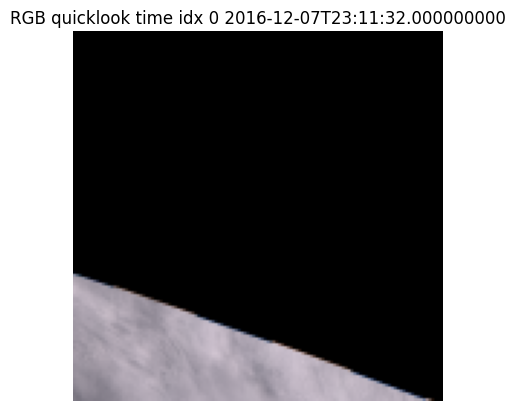

In [21]:
import matplotlib.pyplot as plt

tidx = 0
B04 = int(np.where(ds["band_name"].values == "B04")[0][0])
B03 = int(np.where(ds["band_name"].values == "B03")[0][0])
B02 = int(np.where(ds["band_name"].values == "B02")[0][0])

rgb = np.stack([
    ds["reflectance"].isel(time=tidx, band=B04).values,
    ds["reflectance"].isel(time=tidx, band=B03).values,
    ds["reflectance"].isel(time=tidx, band=B02).values,
], axis=-1)

plt.figure()
plt.title(f"RGB quicklook time idx {tidx} {ds['time'].values[tidx]}")
plt.imshow(np.clip(rgb, 0, 1))
plt.axis("off")
plt.show()
